===== To do:
* loading and preparing data
* building model
* training the model
* inference
* saving and loading model



In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cpu


#### Preparing and Loading Data

In [2]:
# Example - Linear reegression
weight = 0.2
bias = 0.1

START = 0
END = 1
STEP = 0.01

X = torch.arange(START, END, STEP).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400],
         [0.0500],
         [0.0600],
         [0.0700],
         [0.0800],
         [0.0900]]),
 tensor([[0.1000],
         [0.1020],
         [0.1040],
         [0.1060],
         [0.1080],
         [0.1100],
         [0.1120],
         [0.1140],
         [0.1160],
         [0.1180]]))

### Splitting data into training and test sets

In [3]:
len_x = len(X)
len_y = len(y)
print(f'length of X: {len_x} and y: {len_y}')

length of X: 100 and y: 100


In [4]:
# train/test split
train_split = int(0.8 * len_x)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


len(X_train), len(y_train), len(X_test), len(y_test)


(80, 80, 20, 20)

In [5]:
def plot_predictions(train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test, predictions=None):
    """ 
    """

    plt.figure(figsize=(10,7))

    # plotting training data
    plt.scatter(train_data,train_labels, c="b", s=4, label="Training data")
    
    # plottinf test data
    plt.scatter(test_data,test_labels, c="g", s=4, label="Test data")


    # plot predictions
    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label="Predictions")

    plt.legend(prop={"size": 14})
    


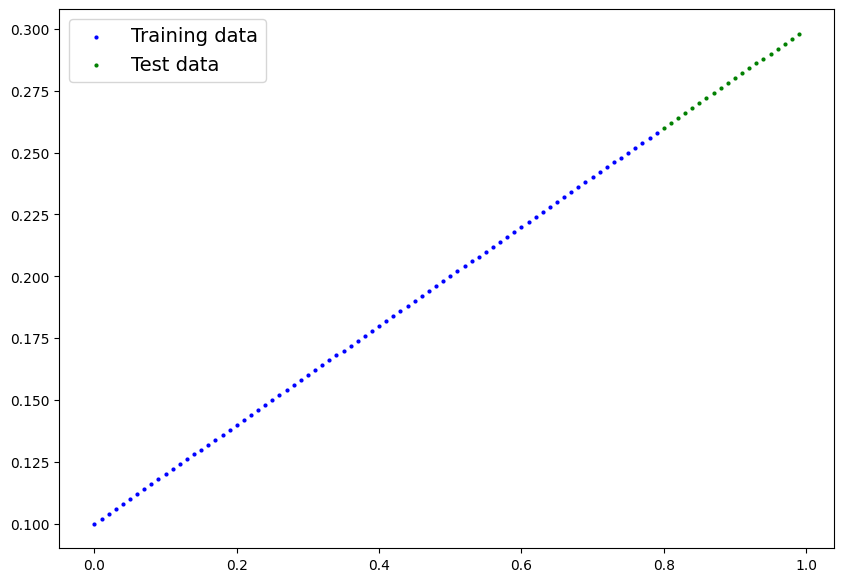

In [6]:
plot_predictions()

In [7]:
# Model class - Linear regression in pytorch

class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    
    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

  # forwar mode
  def forward(self, X: torch.Tensor) -> torch.Tensor:
    return self.weights * X + self.bias
     




## Pytorch model building blocks

* torch.nn - contains building blocks for computational graphs(neural networks)
* torch.nn.Parameter - what parameters model try to learn
* torch.nn.Module - Base class for all neural networks, modules, if subclassed, overwrite forward()
* torch.optim - contains optimizers in PyTorch, they help with optimizing model parameters(e.g gradient descent)
* def forward() - All nn.Module subclasses require ovewrite forward()
* torch.utils.data.Dataset - represent map between key(label) and sample(features) pairs of data
* torc.utils.data.DataLoader - creates python iterable  over a torch Dataset

# checking model internals


In [8]:
# creatin random seed
torch.manual_seed(42)

# model instance
model = LinearRegression()

# checking model parameters
list(model.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# Listing name parameters
print(f'weight: {weight}; Bias: {bias}')
print(model.state_dict())

weight: 0.2; Bias: 0.1
OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [10]:
## making predictions with 'torch.inference_mode()' alternative  'torch.no_grad()'

with torch.inference_mode():
    y_pred = model(X_test)

y_pred

tensor([[0.3982],
        [0.4015],
        [0.4049],
        [0.4083],
        [0.4116],
        [0.4150],
        [0.4184],
        [0.4217],
        [0.4251],
        [0.4285],
        [0.4318],
        [0.4352],
        [0.4386],
        [0.4419],
        [0.4453],
        [0.4487],
        [0.4520],
        [0.4554],
        [0.4588],
        [0.4621]])

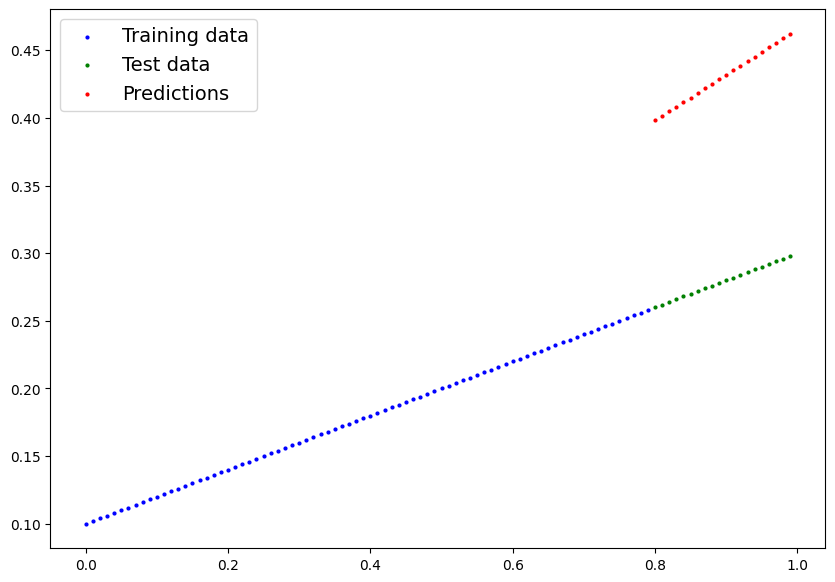

In [11]:
plot_predictions(predictions=y_pred)

#### Training Model


In [12]:
# Setup loss function
loss_fn = nn.L1Loss()   # MAE

# optimizer
optimizer  = torch.optim.SGD(params=model.parameters(),
                            lr=0.001)



#### Training & testing Loop in pytorch

To Do:
* loop through data
* forward pass
* calculate loss
* Optimize
* loss backward - calculates the gradients of each loss of the perameters of our model with respect to the loss (**backpropagation**)
* Optimizer step - adjusts model parameters

In [22]:
torch.manual_seed(42)
epochs = 500

# loop
for epoch in range(epochs):
    # set model to training mode
    model.train()

    # forward pass
    y_pred = model(X_train)

    # calculaing loss
    loss = loss_fn(y_pred, y_train)
    print(f'epoch {epoch}; loss: {loss}, parameters: {model.state_dict()}')

    # optimizer zero grad
    optimizer.zero_grad()

    # backpropagation
    loss.backward()

    # optimizer step
    optimizer.step()
    
    # testing
    model.eval()    # turns off training settings

    

epoch 0; loss: 0.0002868488372769207, parameters: OrderedDict([('weights', tensor([0.2005])), ('bias', tensor([0.1001]))])
epoch 1; loss: 0.0008691787952557206, parameters: OrderedDict([('weights', tensor([0.2001])), ('bias', tensor([0.0991]))])
epoch 2; loss: 0.0002868488372769207, parameters: OrderedDict([('weights', tensor([0.2005])), ('bias', tensor([0.1001]))])
epoch 3; loss: 0.0008691787952557206, parameters: OrderedDict([('weights', tensor([0.2001])), ('bias', tensor([0.0991]))])
epoch 4; loss: 0.0002868488372769207, parameters: OrderedDict([('weights', tensor([0.2005])), ('bias', tensor([0.1001]))])
epoch 5; loss: 0.0008691787952557206, parameters: OrderedDict([('weights', tensor([0.2001])), ('bias', tensor([0.0991]))])
epoch 6; loss: 0.0002868488372769207, parameters: OrderedDict([('weights', tensor([0.2005])), ('bias', tensor([0.1001]))])
epoch 7; loss: 0.0008691787952557206, parameters: OrderedDict([('weights', tensor([0.2001])), ('bias', tensor([0.0991]))])
epoch 8; loss: 0

In [17]:
model.state_dict()

OrderedDict([('weights', tensor([0.2301])), ('bias', tensor([0.0874]))])

In [20]:
# optimizer.state_dict()['param_groups']
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.001,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

In [24]:
with torch.inference_mode():
    preds = model(X_test)
    loss = loss_fn(preds, y_test)

loss

tensor(0.0005)

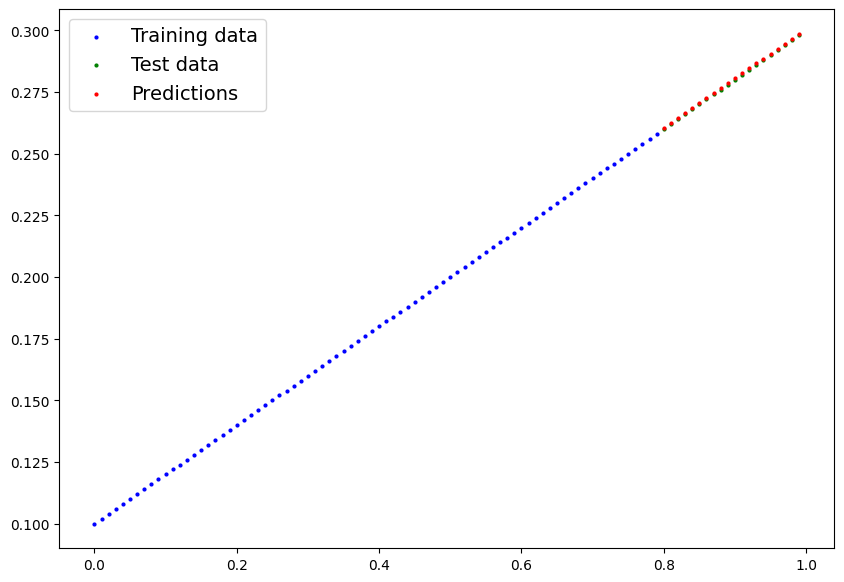

In [26]:
plot_predictions(predictions=preds)

#### Saving model in pytorch

In [44]:
from pathlib import Path


# creating model directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)



# model path
MODEL_NAME = "pytorch_LinearRegression.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME



In [48]:
# saving model state_dict()
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)
print(f'Model saved to: {MODEL_SAVE_PATH}')
 

Saving model to: models\pytorch_LinearRegression.pth
Model saved to: models\pytorch_LinearRegression.pth


In [49]:
ls -l models

 Volume in drive C has no label.
 Volume Serial Number is 00A7-847E

 Directory of c:\Users\user\Documents\dev\deeplearning\pytorch


 Directory of c:\Users\user\Documents\dev\deeplearning\pytorch\models

03/13/2026  02:03 AM    <DIR>          .
03/13/2026  02:03 AM    <DIR>          ..
03/13/2026  02:34 AM             2,093 pytorch_LinearRegression.pth
               1 File(s)          2,093 bytes
               2 Dir(s)  163,832,365,056 bytes free


File Not Found


### loading saved model

To load a saved state_dict() of a saved model, we need to instantiate a new instantce of the model class
 

In [50]:
load_model = LinearRegression()
print(load_model.state_dict())

# Load saved state_dict() 
load_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

print(load_model.state_dict())

OrderedDict([('weights', tensor([1.1103])), ('bias', tensor([-1.6898]))])
OrderedDict([('weights', tensor([0.2005])), ('bias', tensor([0.1001]))])


In [57]:
# Making redictions
load_model.eval()
with torch.inference_mode():
    pred = load_model(X_test)

pred

tensor([[0.2605],
        [0.2625],
        [0.2645],
        [0.2665],
        [0.2685],
        [0.2705],
        [0.2725],
        [0.2745],
        [0.2765],
        [0.2785],
        [0.2805],
        [0.2826],
        [0.2846],
        [0.2866],
        [0.2886],
        [0.2906],
        [0.2926],
        [0.2946],
        [0.2966],
        [0.2986]])

In [58]:
y_test == pred

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

In [56]:
loss = loss_fn(pred, y_test)
print(loss)

tensor(0.0005)


In [ ]:
## comparing model preds with loaded model 
model.eval()
with torch.inference_mode():
    preds = model(X_test)

pred == preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])